<a href="https://colab.research.google.com/github/mendresvon/intro_to_deep_learning_class_notebooks/blob/main/U_Net_Draft_1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install and Import Dependencies
!pip install -Uqq fastai
from fastai.vision.all import *
import numpy as np

In [ ]:
# 2. Download the CamVid_Tiny dataset (Downloads in seconds)
path = untar_data(URLs.CAMVID_TINY)

<div><progress max="2314212" value="2318336"></progress> 100.18% [2318336/2314212 00:00&lt;00:00]</div>

In [ ]:
# 3. Define how to find the pixel masks for each image
# In CamVid, if an image is "0001.png", its mask is usually "0001_P.png"
def get_mask(x):
    return path/'labels'/f'{x.stem}_P{x.suffix}'

In [ ]:
# 4. Load the category codes (e.g., Road, Pedestrian, Car)
codes = np.loadtxt(path/'codes.txt', dtype=str)

In [ ]:
# 5. Build the DataLoaders
# This automatically handles spatial augmentations and maps images to masks
dls = SegmentationDataLoaders.from_label_func(
    path,
    bs=8, # Batch size of 8 fits perfectly on a free T4 GPU
    fnames = get_image_files(path/"images"),
    label_func = get_mask,
    codes = codes
)

In [ ]:
# 6. Initialize the U-Net with a pre-trained ResNet34 backbone
learn = unet_learner(dls, resnet34)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 143MB/s]


In [ ]:
# 7. Train the model
# 6 epochs is enough to get a working proof-of-concept tonight
print("Starting training...")
learn.fine_tune(6)

Starting training...


epoch,train_loss,valid_loss,time
0,3.313207,2.667619,00:08


epoch,train_loss,valid_loss,time
0,2.020653,1.604356,00:05
1,1.684443,1.191638,00:05
2,1.488881,0.994209,00:05
3,1.326188,0.899561,00:05
4,1.196129,0.831043,00:04
5,1.094378,0.797264,00:04


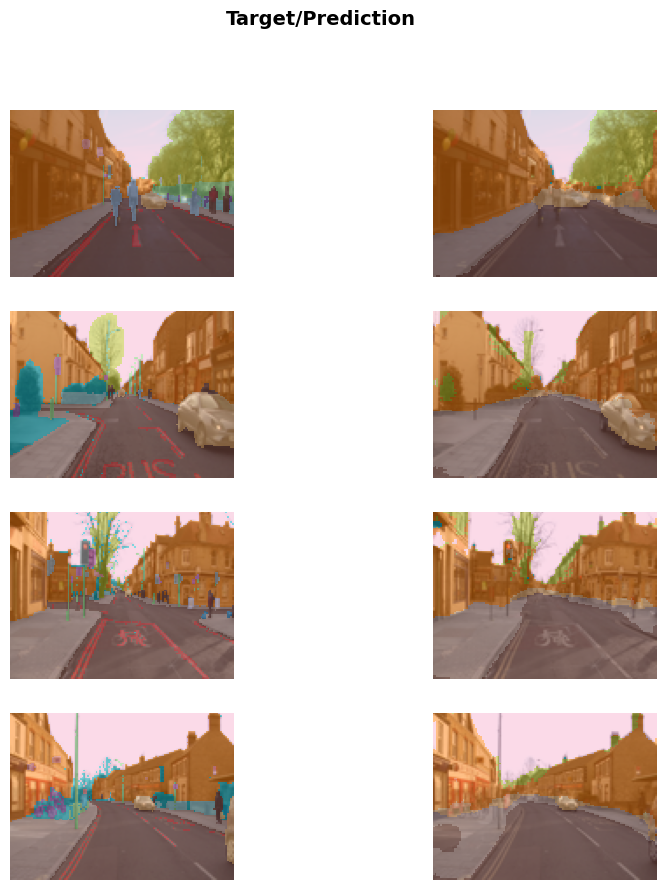

In [ ]:
# 8. Show the results (Take a screenshot of this for your Word report!)
learn.show_results(max_n=4, figsize=(10,10))

In [ ]:
# 9. Export the trained model's "brain"
learn.export('export.pkl')
print("Model exported successfully!")

Model exported successfully!
